In [87]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os
import matplotlib.cm as cm
from io import StringIO

In [88]:
site = "IQ"
ctsm_file = "IQ_1995-2014.nc"
df = xr.open_dataset(ctsm_file, engine="netcdf4")
var_soilt = df["TSOI"]
var_soilt

C:\Users\madel\AppData\Local\Temp\ipykernel_4020\2453725558.py:3: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset(ctsm_file, engine="netcdf4")


<xarray.DataArray 'TSOI' (time: 7300, levgrnd: 25, lndgrid: 1)> Size: 730kB
[182500 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * levgrnd  (levgrnd) float32 100B 0.01 0.04 0.09 0.16 ... 19.48 28.87 42.0
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      soil temperature (natural vegetated and crop landunits only)
    units:          K
    cell_methods:   time: mean
    landunit_mask:  veg

In [89]:
# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv("IQ_obs/soil_temp/borehole_temperatures.csv", parse_dates=["date"])

DEPTH_COLS = [
    "25cm", "50cm", "75cm", "100cm", "150cm", "200cm",
    "300cm", "400cm", "500cm", "600cm", "700cm", "800cm",
    "900cm", "1000cm", "1200cm", "1500cm",
]

depth_cols = [c for c in DEPTH_COLS if c in df.columns]

# ← add this block
depth_m = {
    "25cm": 0.25, "50cm": 0.50, "75cm": 0.75, "100cm": 1.0,
    "150cm": 1.5, "200cm": 2.0, "300cm": 3.0, "400cm": 4.0,
    "500cm": 5.0, "600cm": 6.0, "700cm": 7.0, "800cm": 8.0,
    "900cm": 9.0, "1000cm": 10.0, "1200cm": 12.0, "1500cm": 15.0,
}
# Keep only depth columns that actually exist in the file
depth_cols = [c for c in DEPTH_COLS if c in df.columns]

df = df.sort_values("date")
df



,date,station_code,latitude,longitude,25cm,50cm,75cm,100cm,150cm,200cm,300cm,400cm,500cm,600cm,700cm,800cm,900cm,1000cm,1200cm,1500cm
0,2010-08-25,IQAV2TC,6375421,-6854640,6.69590,5.87971,4.20276,2.379960,0.001918,-0.807765,-2.43875,-3.61477,-4.57251,-5.04816,-5.31967,-5.43488,-5.49457,-5.50060,-5.51455,-5.67539
1,2010-08-26,IQAV2TC,6375421,-6854640,6.58009,5.36575,4.03856,2.395020,0.005377,-0.844169,-2.45523,-3.64966,-4.57474,-5.04777,-5.32536,-5.44245,-5.50272,-5.51164,-5.52513,-5.68464
2,2010-08-27,IQAV2TC,6375421,-6854640,7.34761,5.56304,3.95953,2.340620,0.005910,-0.874011,-2.46663,-3.67484,-4.57511,-5.04565,-5.32875,-5.44789,-5.50945,-5.52065,-5.53400,-5.69218
3,2010-08-28,IQAV2TC,6375421,-6854640,6.18354,5.37008,3.94356,2.331760,0.006605,-0.898370,-2.47334,-3.69254,-4.57422,-5.04202,-5.33095,-5.45184,-5.51464,-5.52780,-5.54155,-5.69898
4,2010-08-29,IQAV2TC,6375421,-6854640,6.44986,5.08089,3.77707,2.295830,0.006760,-0.919024,-2.47872,-3.70541,-4.57177,-5.03784,-5.33081,-5.45461,-5.51872,-5.53394,-5.54833,-5.70409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458,2014-08-25,IQAV2TC,6375421,-6854640,5.71045,4.17222,2.55519,1.075190,-0.617234,-1.532980,-3.26123,-4.77167,-5.69207,-6.13976,-6.35881,-6.33933,-6.21672,-6.05477,-5.69808,-5.55385
1459,2014-08-26,IQAV2TC,6375421,-6854640,6.02710,4.24946,2.52368,1.065260,-0.607757,-1.518830,-3.24020,-4.74833,-5.66986,-6.12120,-6.34554,-6.33143,-6.21287,-6.05409,-5.70028,-5.55459
1460,2014-08-27,IQAV2TC,6375421,-6854640,5.10159,3.92009,2.48167,1.074620,-0.598247,-1.505150,-3.21977,-4.72559,-5.64778,-6.10248,-6.33238,-6.32346,-6.20913,-6.05331,-5.70250,-5.55533
1461,2014-08-28,IQAV2TC,6375421,-6854640,5.19730,3.73778,2.32979,1.023570,-0.589275,-1.491960,-3.19996,-4.70299,-5.62582,-6.08422,-6.31911,-6.31544,-6.20546,-6.05247,-5.70455,-5.55574


In [90]:
for x in df:
    print(x)

date
station_code
latitude
longitude
25cm
50cm
75cm
100cm
150cm
200cm
300cm
400cm
500cm
600cm
700cm
800cm
900cm
1000cm
1200cm
1500cm


In [91]:
var_soilt

<xarray.DataArray 'TSOI' (time: 7300, levgrnd: 25, lndgrid: 1)> Size: 730kB
[182500 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * levgrnd  (levgrnd) float32 100B 0.01 0.04 0.09 0.16 ... 19.48 28.87 42.0
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      soil temperature (natural vegetated and crop landunits only)
    units:          K
    cell_methods:   time: mean
    landunit_mask:  veg

In [92]:
# obs_clean = {}
# for n in observe:
#     observe[n]["obs_t"] = observe[n]["obs_t"]
#     observe[n] = observe[n][observe[n]["obs_depth"] >= 0]
#     observe[n]["time"] = pd.to_datetime(observe[n]["time"])
#     obs_clean.update({f"{n}":observe[n]})
    

# for x in obs_clean:
#   print(obs_clean[x]) 

## Interpolation

defining the interpolation function here

In [93]:
ds = xr.open_dataset(ctsm_file, engine="netcdf4")

def interpolate_to_depth(ds, var, target_depth, depth_dim="levgrnd"):
    sm = ds[var].squeeze()
    depths = ds[depth_dim].values.flatten()
    
    # Convert CFTime to pandas datetime here, once
    cf_times = ds.indexes['time']
    time = pd.to_datetime([f"{t.year}-{t.month:02d}-{t.day:02d}" 
                           for t in cf_times])
    
    # Interpolate
    idx = int(np.searchsorted(depths, target_depth, side="right") - 1)
    idx = int(np.clip(idx, 0, len(depths) - 2))
    z0, z1 = depths[idx], depths[idx + 1]
    w = (target_depth - z0) / (z1 - z0)
    sm_interp = ((1 - w) * sm.values[:, idx] + w * sm.values[:, idx + 1]).flatten()
    
    return xr.DataArray(
        sm_interp,
        coords={"time": time},
        dims=["time"],
        attrs={"units": ds[var].attrs.get("units", ""), 
               "long_name": f"{var} interpolated at {target_depth}m"},
    )


C:\Users\madel\AppData\Local\Temp\ipykernel_4020\1279570558.py:1: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(ctsm_file, engine="netcdf4")


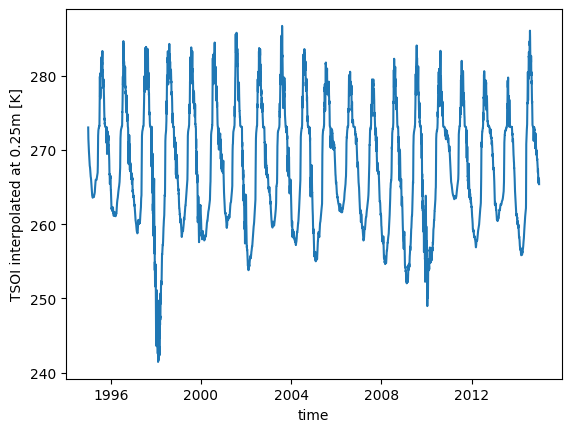

In [94]:
# Usage
da_interp = interpolate_to_depth(ds, "TSOI", target_depth=0.25)
  
da_interp.plot()

## Plotting

defining the plotting funtion for it to be run a few times

In [95]:
def final_plot(IQ_obs, sim, site, deep):
    # Convert pandas → xarray
    obs = IQ_obs.set_index("date").to_xarray()
    
    
    # Resample observational data to daily frequency
    obs_daily = obs.resample(date="1D").mean()
    print("here")

    # Convert K → °C for plotting
    sim_C = sim - 273.15

    plt.figure(figsize=(14,6))

    # Observed (daily)
    plt.plot(
        obs_daily["date"].values,
        obs_daily[f"{deep}cm"].values,
        label="Observed Soil Temperature (C)",
        linewidth=2
    )

    # Simulated
    plt.plot(
        sim_C["time"].values,
        sim_C.values,
        label="Simulated Soil Temperature (C)",
        linewidth=2
    )

    plt.xlabel("Time")
    plt.ylabel("Soil Temperature (C)")
    plt.title(f"Soil Temperature at Iqaluit - {deep}cm")
    plt.grid(True)
    plt.legend()
    plt.savefig(f"0_final_images/{site}_soil_temperature_{deep}.png")
    plt.show()

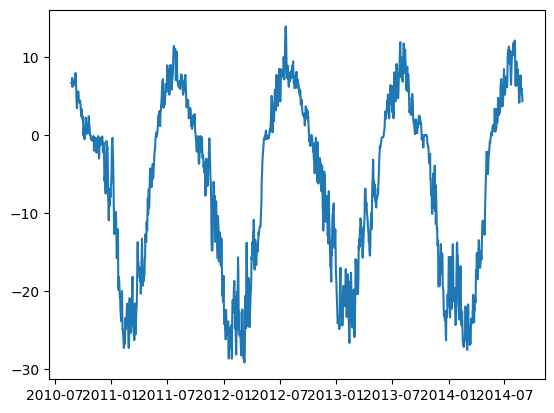

In [96]:
plt.plot(df['date'],df['25cm'])
plt.show()

here


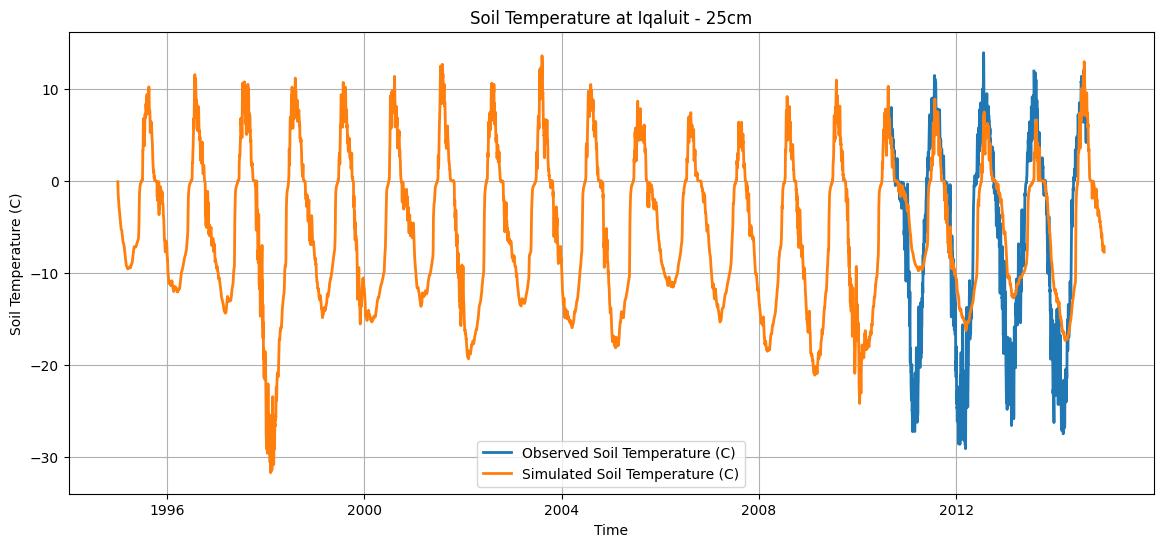

here


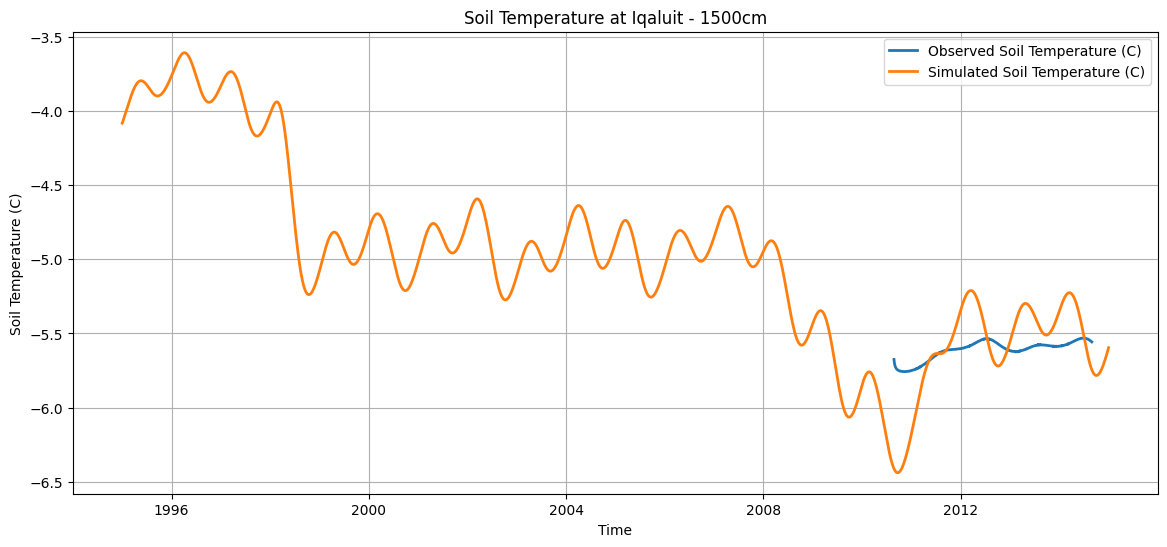

In [97]:
final_plot(df, interpolate_to_depth(ds, "TSOI", target_depth=0.25), site, 25)
final_plot(df, interpolate_to_depth(ds, "TSOI", target_depth=15.0), site, 1500)

## Soil Temperature Profiles for August

August timesteps: 620


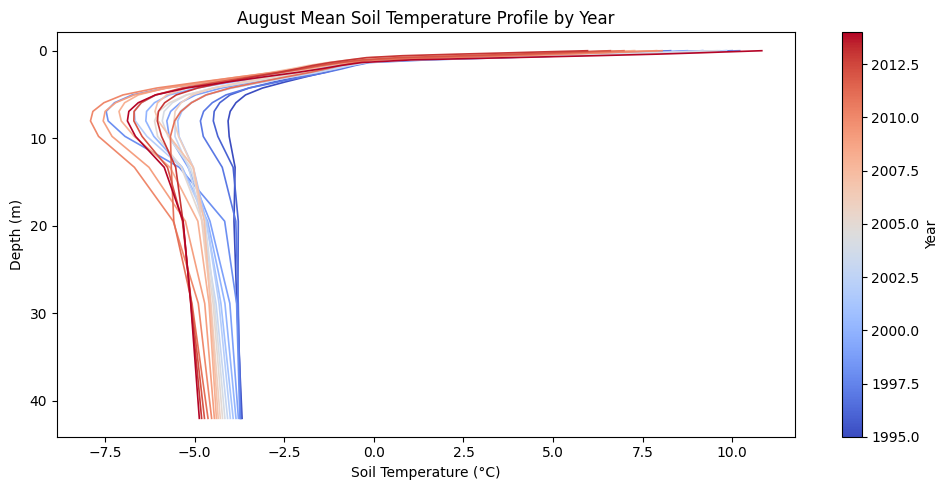

In [98]:
# Load soil temperature — same structure as H2OSOI
st = ds["TSOI"].squeeze()          # shape: (time, levgrnd)
depths = ds["levgrnd"].values.flatten()

# Convert time once
cf_times = ds.indexes['time']
time_pd = pd.to_datetime([f"{t.year}-{t.month:02d}-{t.day:02d}" for t in cf_times])

# Build a DataArray with pandas time index
da_st = xr.DataArray(
    st.values,
    coords={"time": time_pd, "depth": depths},
    dims=["time", "depth"],
    attrs={"units": ds["TSOI"].attrs.get("units", "K"),
           "long_name": "Soil temperature"},
)

# Convert K to °C if needed
if da_st.attrs["units"] == "K":
    da_st = da_st - 273.15
    da_st.attrs["units"] = "°C"

# Filter to August only
da_aug = da_st.sel(time=da_st["time"].dt.month == 8)  # all Augusts across 20 years
print(f"August timesteps: {len(da_aug.time)}")         # should be ~20 x 31 = 620 days

#Individual August profiles, one line per year
years = np.unique(da_aug["time"].dt.year.values)
cmap  = cm.coolwarm(np.linspace(0, 1, len(years)))

fig, ax = plt.subplots(figsize=(10, 5))
for i, year in enumerate(years):
    aug_year = da_aug.sel(time=da_aug["time"].dt.year == year).mean(dim="time")
    ax.plot(aug_year.values, depths, color=cmap[i], linewidth=1.2, label=str(year))

ax.set_xlabel("Soil Temperature (°C)")
ax.set_ylabel("Depth (m)")
ax.set_title("August Mean Soil Temperature Profile by Year")
ax.invert_yaxis()
sm_cbar = plt.cm.ScalarMappable(cmap="coolwarm",
                                 norm=plt.Normalize(years.min(), years.max()))
plt.colorbar(sm_cbar, ax=ax, label="Year")
plt.tight_layout()
plt.show()


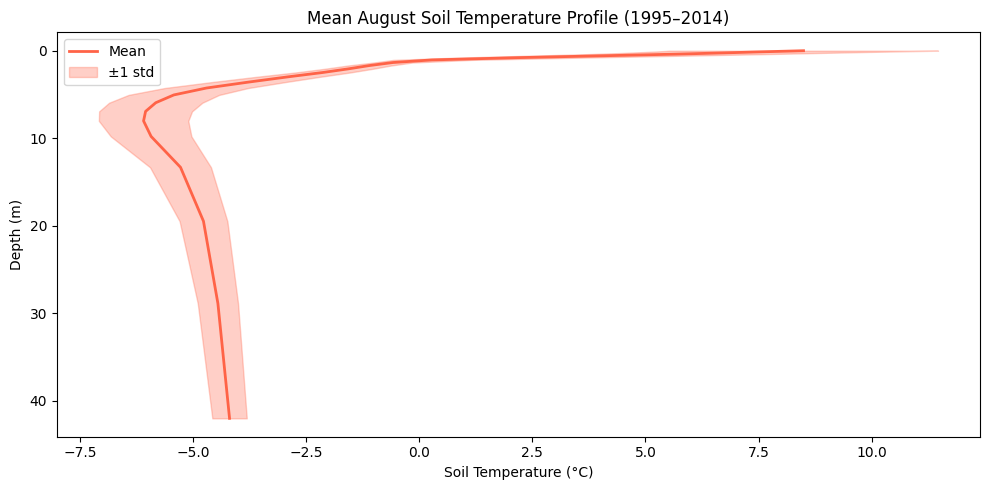

In [99]:
# --- Plot 1: Mean August soil temperature profile ---
aug_mean = da_aug.mean(dim="time")
aug_std  = da_aug.std(dim="time")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(aug_mean.values, depths, color="tomato", linewidth=2, label="Mean")
ax.fill_betweenx(
    depths,
    aug_mean.values - aug_std.values,
    aug_mean.values + aug_std.values,
    alpha=0.3, color="tomato", label="±1 std"
)
ax.set_xlabel("Soil Temperature (°C)")
ax.set_ylabel("Depth (m)")
ax.set_title("Mean August Soil Temperature Profile (1995–2014)")
ax.invert_yaxis()   # surface at top
ax.legend()
plt.tight_layout()
plt.show()

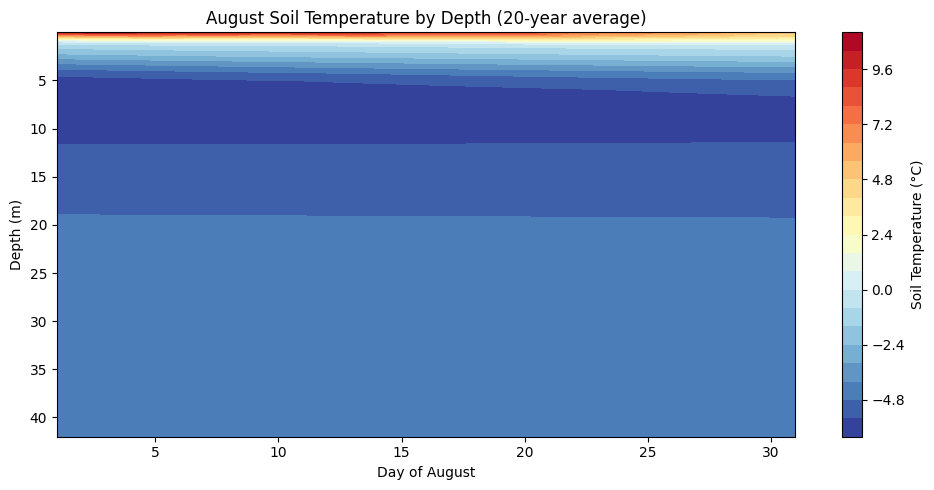

In [100]:

# --- Plot 3: Heatmap — depth vs day-of-August, averaged across all years ---
da_aug_copy = da_aug.assign_coords(doy=("time", da_aug["time"].dt.day.values))
aug_by_day  = da_aug_copy.groupby("doy").mean()   # mean across all 20 Augusts per day

fig, ax = plt.subplots(figsize=(10, 5))
c = ax.contourf(
    aug_by_day["doy"].values,
    depths,
    aug_by_day.values.T,
    levels=25, cmap="RdYlBu_r"
)
plt.colorbar(c, ax=ax, label="Soil Temperature (°C)")
ax.set_xlabel("Day of August")
ax.set_ylabel("Depth (m)")
ax.set_title("August Soil Temperature by Depth (20-year average)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## NOTE

not sure if in this function, I need to be averaging over all AUgust for CTSM, or if I need the dat ranges to match

In [101]:
print(da_aug)
print()
print("Dims:", da_aug.dims)
print("Coords:", list(da_aug.coords))

<xarray.DataArray (time: 620, depth: 25)> Size: 62kB
array([[11.603088 , 10.790253 ,  9.609314 , ..., -3.907013 , -3.8248596,
        -3.6758423],
       [10.872833 , 10.762695 , 10.478577 , ..., -3.9067078, -3.824829 ,
        -3.6759338],
       [11.935516 , 11.381348 , 10.5289   , ..., -3.9064026, -3.8247986,
        -3.6760254],
       ...,
       [ 8.007904 ,  7.8289185,  7.5724792, ..., -5.337036 , -5.1115417,
        -4.8728333],
       [ 7.4334106,  7.4966125,  7.535248 , ..., -5.3381653, -5.111603 ,
        -4.872986 ],
       [ 5.841736 ,  5.9431458,  6.0841064, ..., -5.3392944, -5.111664 ,
        -4.8731384]], shape=(620, 25), dtype=float32)
Coordinates:
  * time     (time) datetime64[us] 5kB 1995-08-01 1995-08-02 ... 2014-08-31
  * depth    (depth) float32 100B 0.01 0.04 0.09 0.16 ... 13.33 19.48 28.87 42.0
Attributes:
    units:      °C
    long_name:  Soil temperature

Dims: ('time', 'depth')
Coords: ['time', 'depth']


Obs depth range: 0.25–15.25 m
Obs time range:  2010-08-25–2014-08-29
CTSM timesteps after time mask: 129


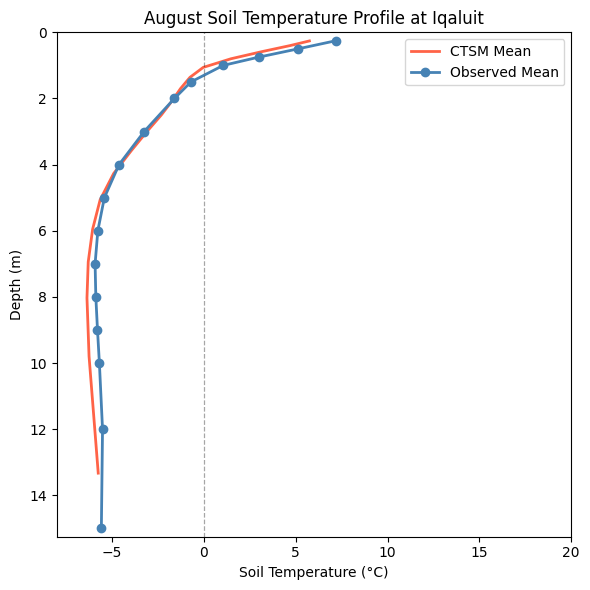

In [103]:
def plot_august_soil_temp_profile(df, da_aug, depths):
    DEPTH_COLS = [
        "25cm", "50cm", "75cm", "100cm", "150cm", "200cm",
        "300cm", "400cm", "500cm", "600cm", "700cm", "800cm",
        "900cm", "1000cm", "1200cm", "1500cm",
    ]
    depth_m_map = {
        "25cm": 0.25, "50cm": 0.50, "75cm": 0.75, "100cm": 1.0,
        "150cm": 1.5,  "200cm": 2.0,  "300cm": 3.0,  "400cm": 4.0,
        "500cm": 5.0,  "600cm": 6.0,  "700cm": 7.0,  "800cm": 8.0,
        "900cm": 9.0,  "1000cm": 10.0, "1200cm": 12.0, "1500cm": 15.0,
    }

    # ── Build obs_df ──────────────────────────────────────────────────────────
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    depth_cols = [c for c in DEPTH_COLS if c in df.columns]

    august = df[df["date"].dt.month == 8]
    obs_records = []
    for col in depth_cols:
        vals = august[col].dropna()
        if len(vals) == 0:
            continue
        obs_records.append({
            "depth_m":   depth_m_map[col],
            "mean_temp": vals.mean(),
            "std_temp":  vals.std(),
        })

    obs_df   = pd.DataFrame(obs_records).sort_values("depth_m").reset_index(drop=True)
    time_min = df["date"].min()
    time_max = df["date"].max()

    # ── Depth range from obs ──────────────────────────────────────────────────
    depth_min = obs_df["depth_m"].min()
    depth_max = obs_df["depth_m"].max() + 0.25
    print(f"Obs depth range: {depth_min}–{depth_max} m")
    print(f"Obs time range:  {time_min.date()}–{time_max.date()}")

    # ── Mask CTSM by time ─────────────────────────────────────────────────────
    ctsm_times = pd.to_datetime(da_aug["time"].values)
    time_min_nl = time_min.tz_localize(None) if time_min.tzinfo else time_min
    time_max_nl = time_max.tz_localize(None) if time_max.tzinfo else time_max
    time_mask     = (ctsm_times >= time_min_nl) & (ctsm_times <= time_max_nl)
    da_aug_masked = da_aug.isel(time=time_mask)
    print(f"CTSM timesteps after time mask: {int(time_mask.sum())}")

    # ── Mask CTSM by depth ────────────────────────────────────────────────────
    depths_arr    = np.array(depths)
    depth_mask    = (depths_arr >= depth_min) & (depths_arr <= depth_max)
    depths_masked = depths_arr[depth_mask]

    # ── CTSM mean/std (already °C, no squeeze needed — shape is time x depth) ─
    aug_mean = da_aug_masked.mean(dim="time").values[depth_mask]
    aug_std  = da_aug_masked.std(dim="time").values[depth_mask]

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot(aug_mean, depths_masked,
            color="tomato", linewidth=2, label="CTSM Mean")
    # ax.fill_betweenx(depths_masked,
    #                  aug_mean - aug_std, aug_mean + aug_std,
    #                  alpha=0.3, color="tomato", label="CTSM ±1 std")

    ax.plot(obs_df["mean_temp"], obs_df["depth_m"],
            color="steelblue", linewidth=2, marker="o", label="Observed Mean")
    # ax.fill_betweenx(obs_df["depth_m"],
    #                  obs_df["mean_temp"] - obs_df["std_temp"],
    #                  obs_df["mean_temp"] + obs_df["std_temp"],
    #                  alpha=0.3, color="steelblue", label="Obs ±1 std")

    ax.set_xlabel("Soil Temperature (°C)")
    ax.set_ylabel("Depth (m)")
    ax.set_title("August Soil Temperature Profile at Iqaluit")
    ax.set_ylim(0, depth_max)
    ax.set_xlim(-8,20)
    ax.axvline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.35, zorder=2)
    ax.invert_yaxis()
    ax.legend()
    plt.tight_layout()
    plt.savefig("0_final_images/IQ_soil_temp_profile.png")
    plt.show()


depths = da_aug["depth"].values
plot_august_soil_temp_profile(df, da_aug, depths)